In [23]:
#Combinación de SINDy, Takens y redes KAN para reconstruir el sistema de Lorenz a partir de una sola variable medida (x)

#------------------------------------------------------------------------------------------------
#Vemos que la función de perdida da "NAN". Puede ser porque las variables son demasiados grandes

#Para solucionarlo, en Lorenz SINDy+Takens+KAN 2.ipynb, normalizamos las variables V_red y Y_medido al rango [-1, 1] antes de pasarlas a tensores.
#Además, decido cambiar x^3 por cos(x) en la red KAN (que toma valores mas pequeños)


In [24]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [25]:
# GENERACIÓN DE DATOS
def lorenz(t,state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

dt = 0.01
t_span = (0, 25)
t_eval = np.arange(t_span[0], t_span[1], dt)
x0 = [-8, 7, 27]

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T

# Medicion parcial: SOLO MEDIMOS LA VARIABLE X
y_medido = X_real[:, 0] 
print(f"Dimensión de y_medido: {y_medido.shape}")

Dimensión de y_medido: (2500,)


In [26]:
#ESPACIO DE RETARDOS (TAKENS / HANKEL)
n_delays = 15  # Dimensión de incrustación
tau = 5        # Retraso temporal

r = len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays)) 
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]

print(f"Dimensión de la matriz de retardos: {X_delay.shape}")

Dimensión de la matriz de retardos: (2430, 15)


In [27]:
#REDUCCIÓN SVD INICIAL 

print("Aplicando SVD...")
U, S, Vt = np.linalg.svd(X_delay, full_matrices=False)
p = 7 # Mantenemos 7 componentes principales
Up = Vt.T[:, :p]

# Datos proyectados al subespacio intermedio
V_red = X_delay @ Up 

# Convertimos a tensores usando las variables (para poder entrenar la red neuronal con PyTorch)
V_tensor = torch.tensor(V_red, dtype=torch.float32)
Y_medido_tensor = torch.tensor(X_delay[:, 0], dtype=torch.float32).view(-1, 1)  #-1 para que deduzca el tamaño de la primera dimensión, 1 para que sea un vector columna
print(f"Dimensión de V_red: {V_red.shape}")
print(f"Dimensión de Y_medido_tensor: {Y_medido_tensor.shape}")

Aplicando SVD...
Dimensión de V_red: (2430, 7)
Dimensión de Y_medido_tensor: torch.Size([2430, 1])


In [28]:
#REDES KAN
class KANLayer(nn.Module):  #es algo así como el nn.Linear, pero en lugar de aplicar una función de activación a la salida, 
                            #aplica una base de funciones univariadas a la entrada y luego aprende a componerlas linealmente
                            
    #En lugar de MLPs estáticos, aplicamos una base de funciones univariadas 
    #[x, x^2, x^3, sin(x)] a cada dimensión de entrada emulando el Teorema de Kolmogorov
    def __init__(self, in_dim, out_dim):
        super(KANLayer, self).__init__()
        self.in_dim = in_dim
        self.n_feat = 4 # Tamaño de la base univariada
        # Matriz de pesos que aprende a componer las funciones de activación
        self.weights = nn.Parameter(torch.randn(in_dim * self.n_feat, out_dim) * 0.1)  #el numero de filas es in_dim * n_feat porque concatenamos 
                                                                                        # las funciones univariadas para cada dimensión de entrada
        self.bias = nn.Parameter(torch.zeros(out_dim))
        
    def forward(self, x):  #x es detamaño (2430,7)
        # Base univariada aplicada a las variables de entrada
        feats = [x, x**2, x**3, torch.sin(x)] #Creo 4 bloques separados de tamaño (2430,7) cada uno, que luego concateno en la siguiente línea
        features = torch.cat(feats, dim=1)
        return features @ self.weights + self.bias



In [29]:
def build_theta_multivar(z):
    #Librería multivariable SINDy para descubrir la EDO
    ones = torch.ones_like(z[:, 0:1])
    z1, z2, z3 = z[:, 0:1], z[:, 1:2], z[:, 2:3]
    return torch.cat([
        ones, z1, z2, z3,
        z1**2, z2**2, z3**2,
        z1*z2, z1*z3, z2*z3
    ], dim=1)


In [30]:
# ARQUITECTURA HÍBRIDA SINDy-TAKENS-KAN
class SINDyTakensKAN(nn.Module):
    def __init__(self, input_dim=7, latent_dim=3):  #Entrego 7 variables de retardo y me devuelven 3 variables latentes
        super(SINDyTakensKAN, self).__init__()
        
        # Encoder KAN  (2 capas sin funciones de activación ocultas porque la KAN ya es no lineal)
        self.enc1 = KANLayer(input_dim, 16)  #Transformo de 7 a 16 dimensiones intermedias
        self.enc2 = KANLayer(16, latent_dim) #Transformo de 16 a 3 dimensiones latentes
        
        # Decoder KAN 
        self.dec1 = KANLayer(latent_dim, 16) #Transformo de 3 a 16 dimensiones intermedias
        self.dec2 = KANLayer(16, input_dim) #Transformo de 16 a 7 dimensiones de salida
        
        # Parámetros Direct SINDy-KAN para la dinámica latente
        self.num_features = 10
        # Matriz de coeficientes (Xi)
        self.xi_din = nn.Parameter(torch.randn(self.num_features, latent_dim) * 0.01)
        # Matriz sombra (Lambda shadow)
        self.lambda_din = nn.Parameter(torch.randn(self.num_features, latent_dim) * 0.01)
        
    def encoder(self, v):
        return self.enc2(self.enc1(v))
        
    def decoder(self, z):
        return self.dec2(self.dec1(z))
        
    def forward(self, v):
        # 1. Transformación al espacio latente usando KAN
        z = self.encoder(v)
        # 2. Reconstrucción SVD usando KAN
        v_recon = self.decoder(z)
        
        # 3. Predicciones usando SINDy-KAN 
        theta_z = build_theta_multivar(z)
        dz_pred_xi = theta_z @ self.xi_din
        dz_pred_lam = theta_z @ self.lambda_din
        
        return z, v_recon, dz_pred_xi, dz_pred_lam

In [31]:
# ENTRENAMIENTO Y FUNCIÓN DE PÉRDIDA 
model = SINDyTakensKAN(input_dim=p, latent_dim=3)  #Recordatorio: p=7 es el número de variables de retardo después de la reducción SVD
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iteraciones = 5000
dt_tensor = torch.tensor(dt, dtype=torch.float32)

# Pesos de la función de pérdida 
lam_recon = 1    # Minimiza la discrepancia del autoencoder
lam_S = 1         # Fidelidad de regresión SINDy 
lam_L = 1         # Fidelidad de regresión sobre la Matriz Sombra
lam_1 = 0.000005    # Dispersión sobre la Matriz Sombra L1
lam_2 = 1.0         # Distancia L2 entre Sombra y Xi
lam_z1 = 0.5        # Anclaje físico (1ª componente)

print("Iniciando el entrenamiento del modelo SINDy-Takens-KAN...")

for k in range(iteraciones):
    optimizer.zero_grad()
    
    z, v_recon, dz_pred_xi, dz_pred_lam = model(V_tensor)
    
    # Derivada empírica latente obtenida por diferencias finitas centrales
    dz_empirico = torch.zeros_like(z)
    dz_empirico[1:-1] = (z[2:] - z[:-2]) / (2 * dt_tensor)
    dz_empirico[0] = (z[1] - z[0]) / dt_tensor
    dz_empirico[-1] = (z[-1] - z[-2]) / dt_tensor
    
    # Bloques de pérdida
    L_recon = nn.functional.mse_loss(v_recon, V_tensor)
    L_S = nn.functional.mse_loss(dz_pred_xi, dz_empirico)      #ns por qué sale en azul
    L_L = nn.functional.mse_loss(dz_pred_lam, dz_empirico)
    L_z1 = nn.functional.mse_loss(z[:, 0:1], Y_medido_tensor)
    L_1 = torch.norm(model.lambda_din, p=1)
    L_2 = torch.mean((model.lambda_din - model.xi_din)**2)
    
    # FUNCIÓN DE PÉRDIDA TOTAL
    loss = (lam_recon * L_recon) + (lam_S * L_S) + (lam_L * L_L) + (lam_1 * L_1) + (lam_2 * L_2) + (lam_z1 * L_z1)
           
    loss.backward()
    optimizer.step()
    
    if (k+1) % 1000 == 0:
        print(f"Iter {k+1}/{iteraciones} | Loss Total: {loss.item():.4f} | "
              f"Recon: {L_recon.item():.4f} | Dinámica(Xi): {L_S.item():.4f} | "
              f"L1(Sombra): {L_1.item():.4f}")

Iniciando el entrenamiento del modelo SINDy-Takens-KAN...
Iter 1000/5000 | Loss Total: nan | Recon: nan | Dinámica(Xi): nan | L1(Sombra): nan
Iter 2000/5000 | Loss Total: nan | Recon: nan | Dinámica(Xi): nan | L1(Sombra): nan
Iter 3000/5000 | Loss Total: nan | Recon: nan | Dinámica(Xi): nan | L1(Sombra): nan
Iter 4000/5000 | Loss Total: nan | Recon: nan | Dinámica(Xi): nan | L1(Sombra): nan
Iter 5000/5000 | Loss Total: nan | Recon: nan | Dinámica(Xi): nan | L1(Sombra): nan


In [32]:
# ECUACIONES DESCUBIERTAS
model.eval()
z_final, _, _, _ = model(V_tensor)

Xi_final = model.xi_din.detach().clone()

# Umbral secuencial
umbral = 0.01
Xi_final[Xi_final.abs() < umbral] = 0.0

print("\n--- SISTEMA DE ECUACIONES DESCUBIERTO . DINÁMICA LATENTE NORMALIZADA ---")
features_names = ["1", "z1", "z2", "z3", "z1^2", "z2^2", "z3^2", "z1z2", "z1z3", "z2z3"]
vars_names = ["dz1/dt", "dz2/dt", "dz3/dt"]

for i in range(3):
    ecuacion = []
    for j in range(10):
        coef = Xi_final[j, i].item()
        if coef != 0:
            ecuacion.append(f"{coef:+.3f}*{features_names[j]}")
            
    if not ecuacion:
        print(f"{vars_names[i]} = 0")
    else:
        print(f"{vars_names[i]} = " + " ".join(ecuacion))


--- SISTEMA DE ECUACIONES DESCUBIERTO . DINÁMICA LATENTE NORMALIZADA ---
dz1/dt = +nan*1 +nan*z1 +nan*z2 +nan*z3 +nan*z1^2 +nan*z2^2 +nan*z3^2 +nan*z1z2 +nan*z1z3 +nan*z2z3
dz2/dt = +nan*1 +nan*z1 +nan*z2 +nan*z3 +nan*z1^2 +nan*z2^2 +nan*z3^2 +nan*z1z2 +nan*z1z3 +nan*z2z3
dz3/dt = +nan*1 +nan*z1 +nan*z2 +nan*z3 +nan*z1^2 +nan*z2^2 +nan*z3^2 +nan*z1z2 +nan*z1z3 +nan*z2z3


In [33]:
# Evaluación cuantitativa
Theta_eval = build_theta_multivar(z_final)
dz_sindy_eval = Theta_eval @ Xi_final  # Usando tu Xi_final con umbral

# Calcular el error cuadrático medio relativo o R^2 para cada dimensión
for i in range(3):
    r2 = 1 - torch.sum((dz_empirico[:, i] - dz_sindy_eval[:, i])**2) / torch.sum((dz_empirico[:, i] - dz_empirico[:, i].mean())**2)
    print(f"R^2 para dz{i+1}/dt: {r2.item():.4f}")


R^2 para dz1/dt: nan
R^2 para dz2/dt: nan
R^2 para dz3/dt: nan


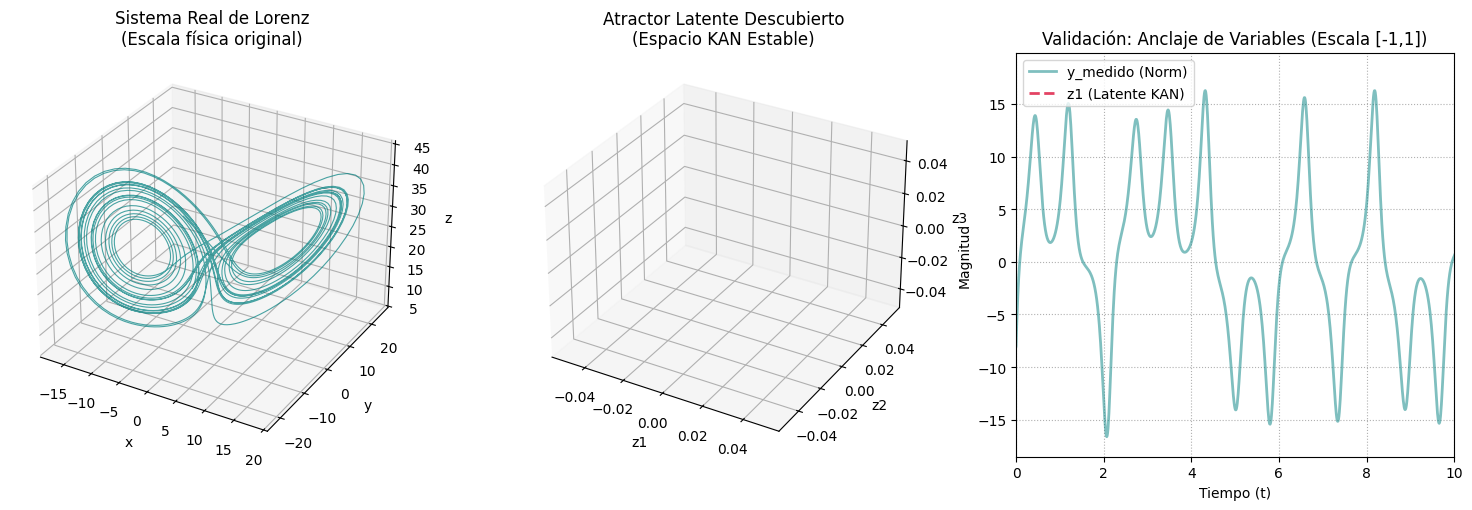

In [34]:
#Graficos
z_np = z_final.detach().numpy()
fig = plt.figure(figsize=(15, 5))

# Subplot 1: Sistema Real de Lorenz
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X_real[:r, 0], X_real[:r, 1], X_real[:r, 2], color='teal', alpha=0.7, linewidth=0.8)
ax1.set_title("Sistema Real de Lorenz\n(Escala física original)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

# Subplot 2: Atractor Latente KAN
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(z_np[:, 0], z_np[:, 1], z_np[:, 2], color='crimson', alpha=0.7, linewidth=0.8)
ax2.set_title("Atractor Latente Descubierto\n(Espacio KAN Estable)")
ax2.set_xlabel("z1"); ax2.set_ylabel("z2"); ax2.set_zlabel("z3")


# Subplot 3: Validación del Anclaje
ax3 = fig.add_subplot(133)
ax3.plot(t_eval[:r], X_delay[:, 0], 'teal', linestyle='-', label='y_medido (Norm)', alpha=0.5, linewidth=2)
ax3.plot(t_eval[:r], z_np[:, 0], 'crimson', linestyle='--', label='z1 (Latente KAN)', alpha=0.8, linewidth=2)
ax3.set_title("Validación: Anclaje de Variables (Escala [-1,1])")
ax3.set_xlabel("Tiempo (t)")
ax3.set_ylabel("Magnitud")
ax3.set_xlim(0, 10)
ax3.grid(True, linestyle=':')
ax3.legend()

plt.tight_layout()
plt.show()